# Baseline Comparisons

## Load Models

In [4]:
import torch
import pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

bart_id = "facebook/bart-large-cnn"
t5_id = "google-t5/t5-base"
model1_id = "Veekee/cmpe-252-summary-project"
model2_id = "../models/checkpoint-11619"

bart_tokenizer = AutoTokenizer.from_pretrained(bart_id)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(bart_id)

t5_tokenizer = AutoTokenizer.from_pretrained(t5_id)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(t5_id)

model1_tokenizer = AutoTokenizer.from_pretrained(model1_id)
model1_model = AutoModelForSeq2SeqLM.from_pretrained(model1_id)

model2_tokenizer = AutoTokenizer.from_pretrained(model2_id)
model2_model = AutoModelForSeq2SeqLM.from_pretrained(model2_id)

Loading weights: 100%|██████████| 512/512 [00:00<00:00, 1182.56it/s, Materializing param=model.shared.weight]                                   


## Generate Summaries by having models use this logic

In [5]:
def generate_summary(text, model, tokenizer):  
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)

    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            num_beams=4,
            max_length=128,
            min_length=30,
            no_repeat_ngram_size=3, # prevents loops
            length_penalty=2.0,     # standard penalty
            early_stopping=True
        )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

In [6]:
from datasets import Dataset

test_df = pd.read_parquet("../data/test_data.parquet")
print(test_df.head())
test_dataset = Dataset.from_pandas(test_df)

                                             article  \
0  for about 20 years the problem of properties o...   
1  it is believed that the direct detection of gr...   
2  as a common quantum phenomenon , the tunneling...   
3  for the hybrid monte carlo algorithm ( hmc)@xc...   
4  recently it was discovered that feynman integr...   

                                            abstract  
0  the short - term periodicities of the daily su...  
1  we study the detectability of circular polariz...  
2  starting from the wkb approximation , a new ba...  
3  we study a novel class of numerical integrator...  
4  new methods for obtaining functional equations...  


## Evaluate

In [7]:
from datasets import Dataset

test_df = pd.read_parquet("../data/test_data.parquet")
test_dataset = Dataset.from_pandas(test_df)


results = []
for sample in tqdm(test_dataset):
    results.append({
        "Reference": sample['abstract'],
        "BART": generate_summary(sample['article'], bart_model, bart_tokenizer),
        "T5-Base": generate_summary(sample['article'], t5_model, t5_tokenizer),
        "Model1": generate_summary(sample['article'], model1_model, model1_tokenizer),
        "Model2": generate_summary(sample['article'], model2_model, model2_tokenizer)
    })

df_results = pd.DataFrame(results)
df_results.head()

  0%|          | 7/6440 [08:16<126:45:10, 70.93s/it]


KeyboardInterrupt: 

## ROUGE & BERTScore

In [14]:
import evaluate
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

def calc_metrics(preds, refs):
    r = rouge.compute(predictions=preds, references=refs)
    b = bertscore.compute(predictions=preds, references=refs, lang="en")
    return {
        "ROUGE": r,
        "BERTScore-F1": sum(b['f1']) / len(b['f1'])
    }

bart_scores = calc_metrics(df_results["BART"], df_results["Reference"])
t5_scores = calc_metrics(df_results["T5-Base"], df_results["Reference"])
model1_scores = calc_metrics(df_results["Model1"], df_results["Reference"])
model2_scores = calc_metrics(df_results["Model2"], df_results["Reference"])

print("BART Scores: ", bart_scores)
print("T5 Scores: ", t5_scores)
print("Model1 Scores: ", model1_scores)
print("Model2 Scores: ", model2_scores)

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 1423.94it/s, Materializing param=encoder.layer.23.output.dense.weight]              
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BART Scores:  {'ROUGE': {'rouge1': np.float64(0.28088235294117647), 'rouge2': np.float64(0.0625), 'rougeL': np.float64(0.2514705882352941), 'rougeLsum': np.float64(0.2514705882352941)}, 'BERTScore-F1': 0.9196314811706543}
T5 Scores:  {'ROUGE': {'rouge1': np.float64(0.3270944741532977), 'rouge2': np.float64(0.09475806451612903), 'rougeL': np.float64(0.23885918003565063), 'rougeLsum': np.float64(0.23885918003565063)}, 'BERTScore-F1': 0.919925719499588}
Model1 Scores:  {'ROUGE': {'rouge1': np.float64(0.29444444444444445), 'rouge2': np.float64(0.058823529411764705), 'rougeL': np.float64(0.26666666666666666), 'rougeLsum': np.float64(0.26666666666666666)}, 'BERTScore-F1': 0.9181161522865295}
Model2 Scores:  {'ROUGE': {'rouge1': np.float64(0.18962962962962962), 'rouge2': np.float64(0.057692307692307696), 'rougeL': np.float64(0.1711111111111111), 'rougeLsum': np.float64(0.1711111111111111)}, 'BERTScore-F1': 0.8990259766578674}


## Visualize Scores

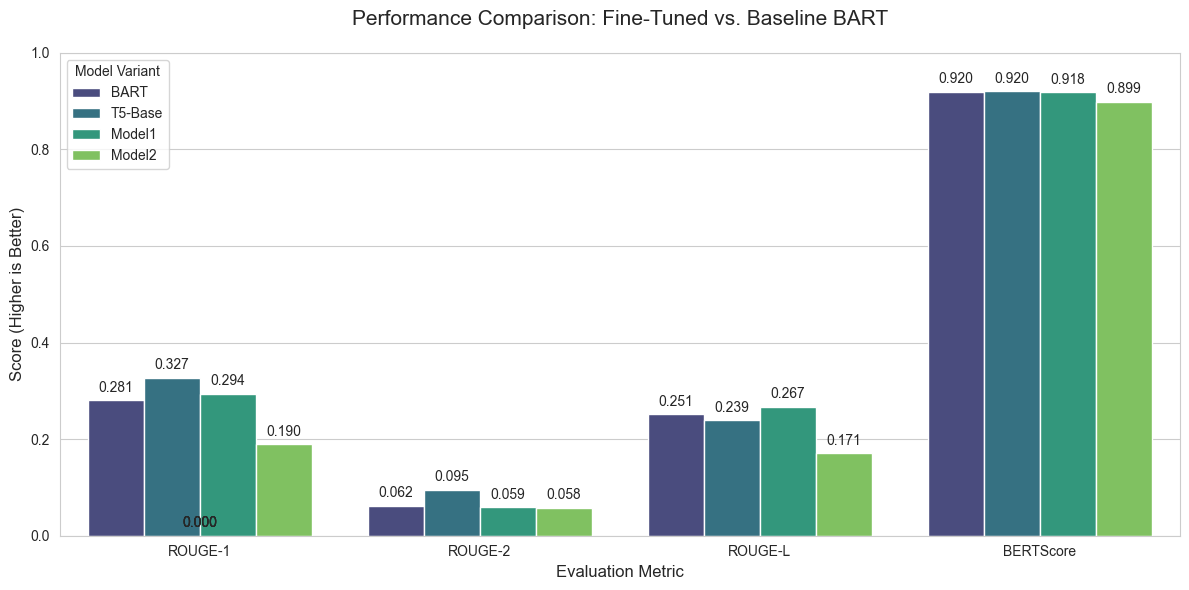

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_data = {
    "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore"],
    "BART": [
        bart_scores["ROUGE"]["rouge1"],
        bart_scores["ROUGE"]["rouge2"],
        bart_scores["ROUGE"]["rougeL"],
        bart_scores["BERTScore-F1"]
    ],
    "T5-Base": [
        t5_scores["ROUGE"]["rouge1"],
        t5_scores["ROUGE"]["rouge2"],
        t5_scores["ROUGE"]["rougeL"],
        t5_scores["BERTScore-F1"]
    ],
    "Model1": [
        model1_scores["ROUGE"]["rouge1"],
        model1_scores["ROUGE"]["rouge2"],
        model1_scores["ROUGE"]["rougeL"],
        model1_scores["BERTScore-F1"]
    ],
    "Model2": [
        model2_scores["ROUGE"]["rouge1"],
        model2_scores["ROUGE"]["rouge2"],
        model2_scores["ROUGE"]["rougeL"],
        model2_scores["BERTScore-F1"]
    ]
}

df_plot = pd.DataFrame(metrics_data)
# don't know what this is yet
df_melted = df_plot.melt(id_vars="Metric", var_name="Model", value_name="Score")

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# bar chart
bar_chart = sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette="viridis")

# styling
plt.title("Performance Comparison: Fine-Tuned vs. Baseline BART", fontsize=15, pad=20)
plt.ylim(0, 1.0)
plt.ylabel("Score (Higher is Better)", fontsize=12)
plt.xlabel("Evaluation Metric", fontsize=12)
plt.legend(title="Model Variant", loc='upper left')

# add labels to bars
for p in bar_chart.patches:
    bar_chart.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10)

plt.tight_layout()
plt.show()